Деятельность групповой работы на 100% выполнена студентом группы 235 Колосковым Сергеем в связи с незаинтересованностью и невовлеченностью остальных участников команды в проектную деятельность по дисциплине.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
d = pd.read_csv('data_ab.csv')
d.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1


In [ ]:
d.shape

(294478, 5)

In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [ ]:
d.isna().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0


In [ ]:
d.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [ ]:
d.describe(include='object')

,timestamp,group,landing_page
count,294478,294478,294478
unique,294478,2,2
top,2025-01-16 12:40:24.467417,treatment,old_page
freq,1,147276,147239


In [ ]:
d['user_id'].nunique()

290584

Мы загрузили и считали датасет, установили, что значения в нем действительно соответствуют поставленной задаче. Далее, исследовали его структуру: мы имеем 5 признаков, которые характеризуют A/B - тестирование. Данные признаки загружены в ожидаемом и необходимом для дальнейшего взаимодействия типе данных. В датасете нет пропусков, а признаки group и landing_page имеют два уникальных значения. В совокупности эти факторы дают зеленый свет для дальнейшего взаимодействия с датасетом. Но также стоит заметить, что количество уникальных пользователей не совпадает с количеством записей, что является триггером для того, чтобы понять природу этих дупликатов.

**EDA**

In [ ]:
d['group'].value_counts()

,count
group,
treatment,147276
control,147202


In [ ]:
d['landing_page'].value_counts()

,count
landing_page,
old_page,147239
new_page,147239


Здесь можно заметить второй стоп-сигнал: имеем, что людей, входящих в контрольную группу меньше, чем посетителей новой версии страницы, а число входящих в экспериментальную группу больше, чем посетителей старой версии страницы.

In [ ]:
d['converted'].value_counts()

,count
converted,
0,259241
1,35237


In [ ]:
d['converted'].mean()

np.float64(0.11965919355605512)

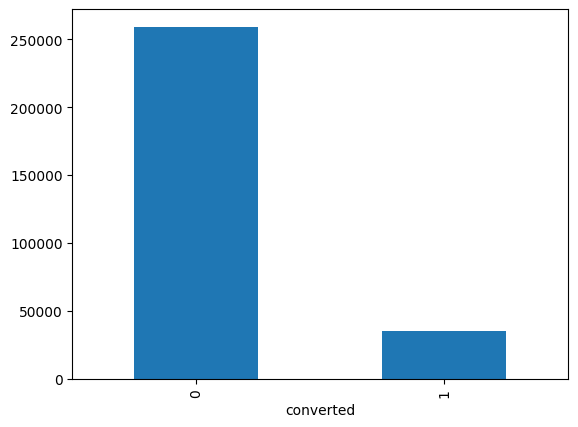

In [ ]:
d['converted'].value_counts().plot(kind='bar')
plt.show()

Анализ имеющегося исследования показал, что распределение пользователей на группы хоть и оказалось приблизительно равномерным: в контрольную группу вошло 147202 пользователя, а в экспериментальную 147276 человек, но эта разница создает повод для проверки данного показателя. Распределение версий лендинга оказалось идеальным: 147239 пользователей в обоих версиях страницы. Целевое действие - регистрация на курс совершило лишь 35 237 пользователей, когда оставшиеся 259241 "прошли мимо". Общая конверсия имеет показатель 0.11965919355605512, что приблизительно равно 12%. То есть всего 12% людей зарегистрировались на курс. За основную метрику выбрана как раз таки конверсия, так как именно она отражает успешный результат, что и будет являться выводом из исследуемого тестирования.

**Проверка корректности исследования**

In [ ]:
a = d[(d['group'] == 'control') & (d['landing_page'] == 'new_page')]
b = d[(d['group'] == 'treatment') & (d['landing_page'] == 'old_page')]

len(a) + len(b)

3893

In [ ]:
a.shape[0]

1928

In [ ]:
b.shape[0]

1965

In [ ]:
d['user_id'].duplicated().sum()

np.int64(3894)

In [ ]:
d['user_id'].nunique()

290584

По условию проведения A/B теста контрольная группа должна была видеть старую версию страницы, а экспериментальная группа - новую. Данное правило нарушается 3893 раза в данных. Из этих нарушений 1928 пользователей, которые относятся к контрольной группе, но видели новую страницу и 1965 пользователей, которые относятся к экспеприментальной группе, но видели старую страницу. Для начала нужно обозначить природу этих погрешностей, после чего "неправильные" строки необходимо удалить для более корректных результатов тестирования. Также датасет содержит дупликаты, которых насчитывается 3894. Они тоже подлежат обработке.

In [ ]:
u = d[(d['group'] == 'control') & (d['landing_page'] == 'new_page')]['user_id'].iloc[0]
d[d['user_id'] == u]

,user_id,timestamp,group,landing_page,converted
22,767017,2025-01-12 22:58:14.991443,control,new_page,0
277989,767017,2025-01-08 01:31:31.456648,treatment,new_page,0


In [ ]:
x = d.groupby('user_id').agg({
    'group':'nunique',
    'landing_page':'nunique'
})
u = x[(x['group'] > 1) & (x['landing_page'] == 1)].index
y = d[d['user_id'].isin(u)].sort_values(['user_id', 'timestamp'])
y[['user_id', 'timestamp', 'group', 'landing_page', 'converted']]

,user_id,timestamp,group,landing_page,converted
207211,630320,2025-01-07 18:02:43.626318,control,old_page,0
255753,630320,2025-01-12 05:27:37.181803,treatment,old_page,0
73599,630805,2025-01-12 20:45:39.012189,treatment,old_page,0
39852,630805,2025-01-22 12:01:15.144329,control,old_page,0
18596,630871,2025-01-03 05:23:01.269988,treatment,old_page,0
...,...,...,...,...,...
32034,945369,2025-01-24 08:20:11.861088,treatment,old_page,0
183169,945387,2025-01-03 01:12:35.747597,treatment,new_page,0
275158,945387,2025-01-20 02:12:45.553852,control,new_page,0
49419,945627,2025-01-06 00:03:20.474879,control,new_page,1


In [ ]:
x = d.groupby('user_id').agg({
    'group':'nunique',
    'landing_page':'nunique'
})
u = x[(x['group'] == 1) & (x['landing_page'] > 1)].index
z = d[d['user_id'].isin(u)]
z = z.sort_values(['user_id', 'timestamp'])
z = z.reset_index(drop=True)
z[['user_id', 'timestamp', 'group', 'landing_page', 'converted']]

,user_id,timestamp,group,landing_page,converted
0,630052,2025-01-07 12:25:54.089486,treatment,old_page,1
1,630052,2025-01-17 01:16:05.208766,treatment,new_page,0
2,630126,2025-01-14 13:35:54.778695,treatment,old_page,0
3,630126,2025-01-19 17:16:00.280440,treatment,new_page,0
4,630137,2025-01-20 02:08:49.893878,control,old_page,0
...,...,...,...,...,...
3991,945703,2025-01-18 06:39:31.294688,control,old_page,0
3992,945797,2025-01-11 03:04:49.433736,control,new_page,1
3993,945797,2025-01-13 17:23:21.750962,control,old_page,0
3994,945971,2025-01-16 10:09:18.383183,control,old_page,0


В целом, природа ошибок довольно туманна. Есть 1998 пользователей, которые по какой-то причине были определены в одну из групп, но при этом увидели обе версии страниц, а также 1895 пользователей, которые дважды были отнесены в разные группы, но при этом посещали одну и ту же страницу. Это могло произойти из-за ошибки объединения таблиц или из-за того, что после назначения пользователя, он почистил COOKIES, что не завершило его сессию, но при этом переназначило ему группу/показало другую страницу. К сожалению, второй вариант догадки неверный, как и, наверняка, первый, так как даты сессий различны, что делает второй вариант невозможным, а первый вариант звучит слишком неубедительно (в него даже я не верю). Так или иначе предстоит избавиться от некорректных данных, а именно удалим те строки, в которых контрольная группа видела новую версию страницы, а экспериментальная старую, так как это противоречит логике всего тестирования.

In [ ]:
d = d[((d['group'] == 'control') & (d['landing_page'] == 'old_page')) | ((d['group'] == 'treatment') & (d['landing_page'] == 'new_page'))]
d.shape

(290585, 5)

In [ ]:
d.groupby('group')['converted'].mean()

,converted
group,
control,0.120386
treatment,0.118807


In [ ]:
d['group'].value_counts(normalize=True)

,proportion
group,
treatment,0.500064
control,0.499936


Анализ размерностей групп показал почти идеальный результат, практически 50 на 50 для экспериментальной и контрольной группы соответственно. В конверсии разница также минимальна: 12.04% для контрольной и 11.89% для экспериментальной.

In [ ]:
d['timestamp'] = pd.to_datetime(d['timestamp'])

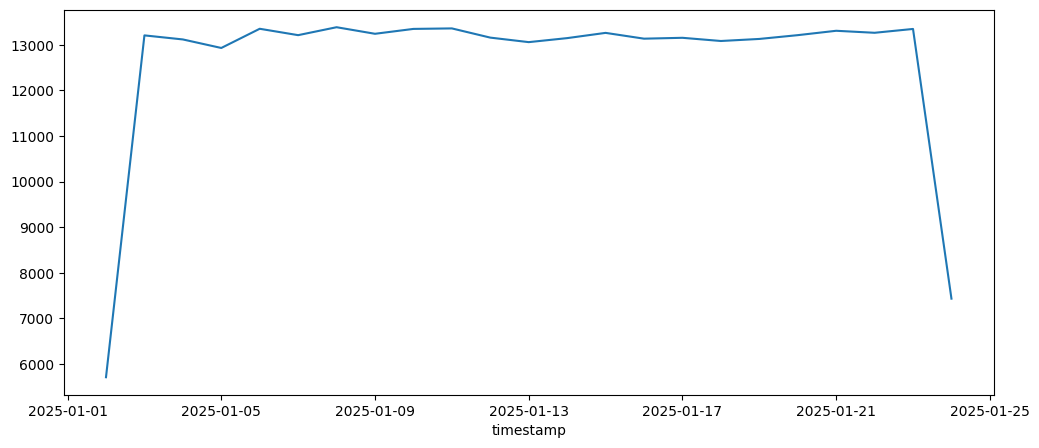

In [ ]:
x = d.groupby(d['timestamp'].dt.date)['user_id'].count()
x.plot(figsize=(12,5))
plt.show()

Анализ временных меток показал равномерное распределение участников практически во всем периоде исследования. В исключения попали первые и последние дни. Скорее всего, это обусловлено неполнотой собранных данных, но, так или иначе, эта погрешность не имеет существенного влияния на результат.

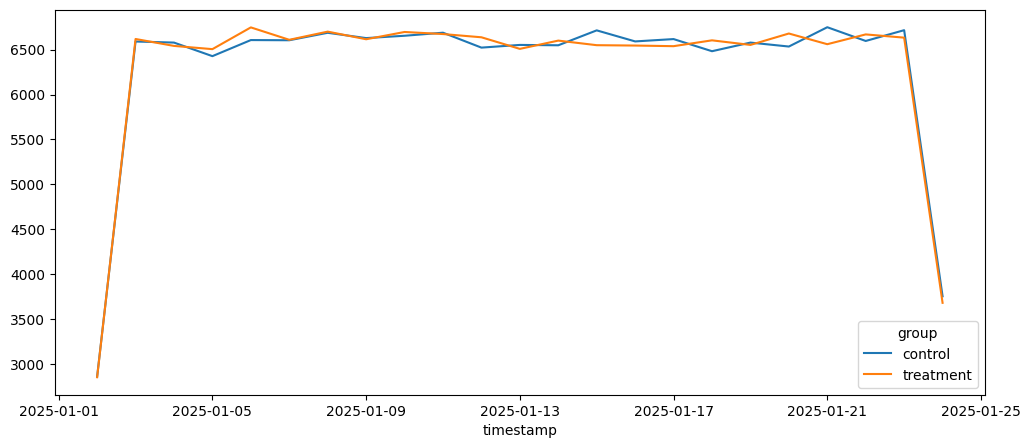

In [ ]:
x = d.groupby([d['timestamp'].dt.date,'group'])['user_id'].count().unstack()
x.plot(figsize=(12,5))
plt.show()

То же самое видно и для графиков разделения на группы. Это свидетельствует об отсутствии какой-либо зависимости от времени или сезона. Обе группы равномерно распределяются по всему временному промежутку.

In [ ]:
a = d[d['group'] == 'control'].copy()
a['x'] = np.random.randint(0, 2, len(a))
a.groupby('x')['converted'].mean()

,converted
x,
0,0.119854
1,0.120917


Далее был выполнен упрощенный A/A тест, в ходе которого контрольная группа была разделена на две рандомные части, но при этом конверсия на обоих частях имеет минимальное различие: 11,99% против 12,09%, что свидетельствует о том, что механизм распределения для исследования работал верно.

**Формулировки нулевой и альтернативной гипотез**

Нулевая гипотеза: конверсия пользователей на разных версиях страницы не различается

Альтернативная гипотеза: конверсия пользователей на разных версиях страницы различается

Данные гипотезы отвечают на важный вопрос для бизнес-заказчика: стоит ли тратить деньги на развитие и поддержание новой странички. В целом, со стороны заказчика на уже имеющееся тестирование может поступить вполне логичный вопрос: "Ну вот вы получили процент конверсии 12.04% для старого сайта и 11.89% для нового. Мы не будем внедрять и поддерживать нововведение, в нем нет смысла", и при этом с заказчиком будет трудно поспорить и донести до него, что вполне вероятно, если провести такой же тест еще раз, то скорее всего результат еще раз изменится, потому что такие минимальные колебания - вполне обычная и нормальная ситуация. А если бы мы и провели повторный тест и получили бы, что новая версия имеет конверсию выше (тоже незначительно), а заказчик бы на результаты теста сразу сказал "внедряем", то это тоже бы являлось ошибкой с его стороны, так как есть большая вероятность, что принятые компанией решения могут быть сделаны на основе шума. И тут самым крепким аргументом будет являться как раз таки проверка данных гипотез. Она покажет действительно ли изменение сайта повлияло на конверсию, или же это просто статистическая погрешность и разницы в сайтах действительно нет.

Для проверки будем использовать z-тест для двух долей. Этот метод применим, так как пользователи контрольной и экспериментальной групп независимы друг от друга, целевая переменная - конверсии является бинарной, распределение на группы равномерное. Уровень значимости обозначим за alpha = 0.05.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
a = 0.05
s1 = d[d['group'] == 'control']['converted'].sum()
s2 = d[d['group'] == 'treatment']['converted'].sum()
n1 = d[d['group'] == 'control'].shape[0]
n2 = d[d['group'] == 'treatment'].shape[0]
z, p = proportions_ztest([s1, s2], [n1, n2])
print('z =', z)
print('p =', p)
if p < a:
    print('Отвергаем H0')
else:
    print('Не отвергаем H0')

z = 1.3116075339133115
p = 0.18965258971881804
Не отвергаем H0


А это значит, что результаты z-теста не отклоняют нулевую гипотезу при уровне alpha = 0.05. Данный вывод можно интерпретировать как факт того, что разницу в конверсиях старой и новой версией сайта не является статистически значимой. Следовательно, на основании имеющихся данных нельзя сделать вывод о том, что новая версия влияет на вероятность регистрации на курс. Это значит, что нет оснований полагать, что новая версия лучше старой, но также и нет оснований утверждать, что старая версия лучше новой.

Также используем Bootstrap для доверительного интервала, чтобы дополнительно проверить нашу гипотезу. Он применим по тем же признакам, но в нем нас интересуют не сами конверсии, а разница между разными версиями сайта.

In [ ]:
c = d[d['group'] == 'control']['converted']
t = d[d['group'] == 'treatment']['converted']
r = []
for i in range(5000):
    a = c.sample(len(c), replace=True).mean()
    b = t.sample(len(t), replace=True).mean()
    r.append(b - a)
r = np.array(r)

In [ ]:
np.percentile(r, [2.5, 97.5])

array([-0.00394689,  0.00075429])

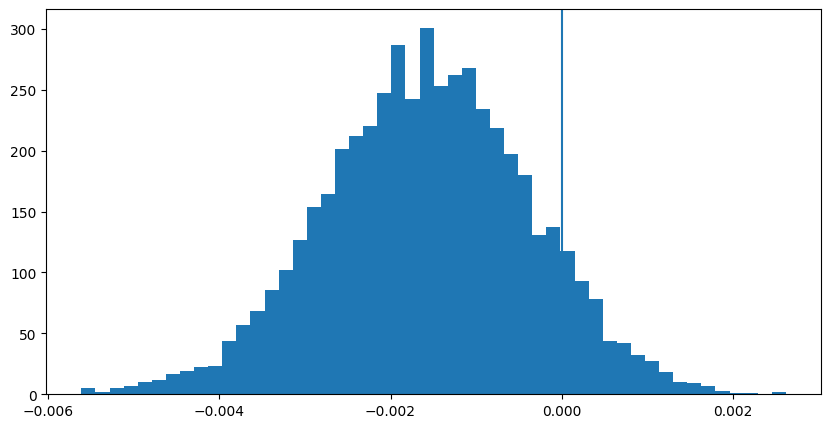

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(r, bins=50)
plt.axvline(0)
plt.show()

Результаты бутстрепа уже повеселее: левая граница показывает, что в худшем, но при этом реальном случае новая страница снижает конверсию на 0,395%, а в лучшем увеличивает ее на 0,075%. Но этот интервал содержит в себе 0, что опять же является знаком того, что нулевая гипотеза не отвергается.

Можно бы было уже отчаяться и забыть про это исследование, но считаю целесообразным проверить еще 1 метод, а именно: анализ чувствительности к обработке данных, то есть проверить, повлияла ли очистках тех самых проблемных строк на конверсию.

К сожалению, я не обладаю навыками этики программирования, поэтому изначально допустил ошибку в виде переназначения переменной d после очистки от пропусков. Поэтому придется считывать файл снова.

In [ ]:
r = pd.read_csv('data_ab.csv')

In [ ]:
x1 = r[r['group'] == 'control']['converted'].mean()
x2 = r[r['group'] == 'treatment']['converted'].mean()
print(x1)
print(x2)

0.12039917935897611
0.11891957956489856


In [ ]:
y1 = d[d['group'] == 'control']['converted'].mean()
y2 = d[d['group'] == 'treatment']['converted'].mean()

print(y1)
print(y2)

0.1203863045004612
0.11880724790277405


In [ ]:
z = pd.DataFrame({
    'До очистки':[x1, x2],
    'После очистки':[y1, y2]
}, index=['control', 'treatment'])
z

,До очистки,После очистки
control,0.120399,0.120386
treatment,0.118920,0.118807


Визуально выглядит так, будто бы все таки стоило остановиться, потому что визуально все понятно, что разницы нет практически никакой. Но все также стоит проверить эту разницу в соответствии со статистическими методами. Снова прибегнем к z-тесту.

In [ ]:
s1 = r[r['group'] == 'control']['converted'].sum()
s2 = r[r['group'] == 'treatment']['converted'].sum()
n1 = r[r['group'] == 'control'].shape[0]
n2 = r[r['group'] == 'treatment'].shape[0]
z, p = proportions_ztest([s1, s2], [n1, n2])
print(z)
print(p)

1.2369217547321678
0.21611613269757501


В общем, для уровня значимости альфа = 0.05 все такой же вывод: не отвергаем нулевую гипотезу.

**Выводы для бизнеса**

Общие выводы заключаются в том, что разница в конверсии хоть и минимальная, но не в пользу нового варианта, а проверка гипотезы показала, что при уровне значимости альфа = 0.05 между сайтами нет статистических отличий: ни один из них не лучше другого. При этом при проверки данных критических неточностей и ошибок не было обнаружено, а небольшая проблемка в виде "странных" данных была исправлена (при этом данные не оказались чувствительными к этому изменению).

На основании всего вышеизложенного, я бы рекомендовал не выпускать новый сайт в том виде, в котором он уже есть. Если затраты на реализацию обновления не были велики, то возможно, стоит рассмотреть возможность отката к старой версии и дальнейшей работы над ней, либо же необходимы дополнительные вложения, которые бы были способны развить новую страничку. Во втором случае необходимо незамедлительно заняться выявлением причины, по которой новый сайт не принес ожидаемого результата.